In [1]:
result_path = 'result.csv' # @param {'type':'string'}
buff_dir = 'buff_icons' # @param {'type':'string'}
debuff_dir = 'debuff_icons' # @param {'type':'string'}
use_pct = True # @param {type:"boolean"}

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv(result_path)

# 2. Clean the 'dmg_ba' text column into actual numeric types
def clean_damage_ba(val):
    if pd.isna(val): return np.nan
    val = str(val).replace('"', '').replace(',', '').strip()
    # Fix common video OCR typos (like letters substituted for numbers)
    if val.endswith('k'):
        return float(val[:-1]) * 1000
    return float(val)

def clean_damage_pct(val):
    if pd.isna(val): return np.nan
    val = float(val)
    return val/10 #miss out decimal point

In [3]:
df['dmg_ba_numeric'] = df['dmg_ba'].apply(clean_damage_ba)
df['dmg_ba_numeric'] = df['dmg_ba_numeric'].interpolate()
df['interval_dmg'] = df['dmg_ba_numeric'].diff().fillna(0)

df_negative_damage = df[df['interval_dmg'] < 0]
print(df_negative_damage.shape[0], "rows with negative damage")
df_negative_damage[['timestamp', 'dmg_ba', 'interval_dmg']].head(5)

36 rows with negative damage


,timestamp,dmg_ba,interval_dmg
65,104.37,"324,048,976,490k",-4.836060e+13
71,110.31,"317,981,495,265k",-1.048161e+13
80,119.22,"31,225,422,899k",-3.485864e+14
82,121.19,"31,632,605,782k",-3.595928e+14
97,136.04,"119,506,807,065k",-2.977515e+14


In [4]:
header_name=""
numeric_header_name = ""
interval_header_name = ""
for header_name in df.columns:
    if not header_name.endswith("_pct"):
        continue
    numeric_header_name = f'{header_name}_numeric'
    interval_header_name = f'{header_name}_interval'
    df[numeric_header_name] = df[header_name].apply(clean_damage_pct)
    df[interval_header_name] = -df[numeric_header_name].diff().fillna(0)
    print(header_name)
    df_negative_damage = df[df[interval_header_name] < 0]
    print(df_negative_damage.shape[0], "rows with negative damage")
    print(df_negative_damage[['timestamp', numeric_header_name, interval_header_name]].head(5))

boss_pct
43 rows with negative damage
    timestamp  boss_pct_numeric  boss_pct_interval
9       48.92              98.0             -88.08
13      52.88              92.0             -82.60
20      59.80              83.6             -75.20
26      65.76              79.3             -71.30
28      67.73              78.4             -70.52


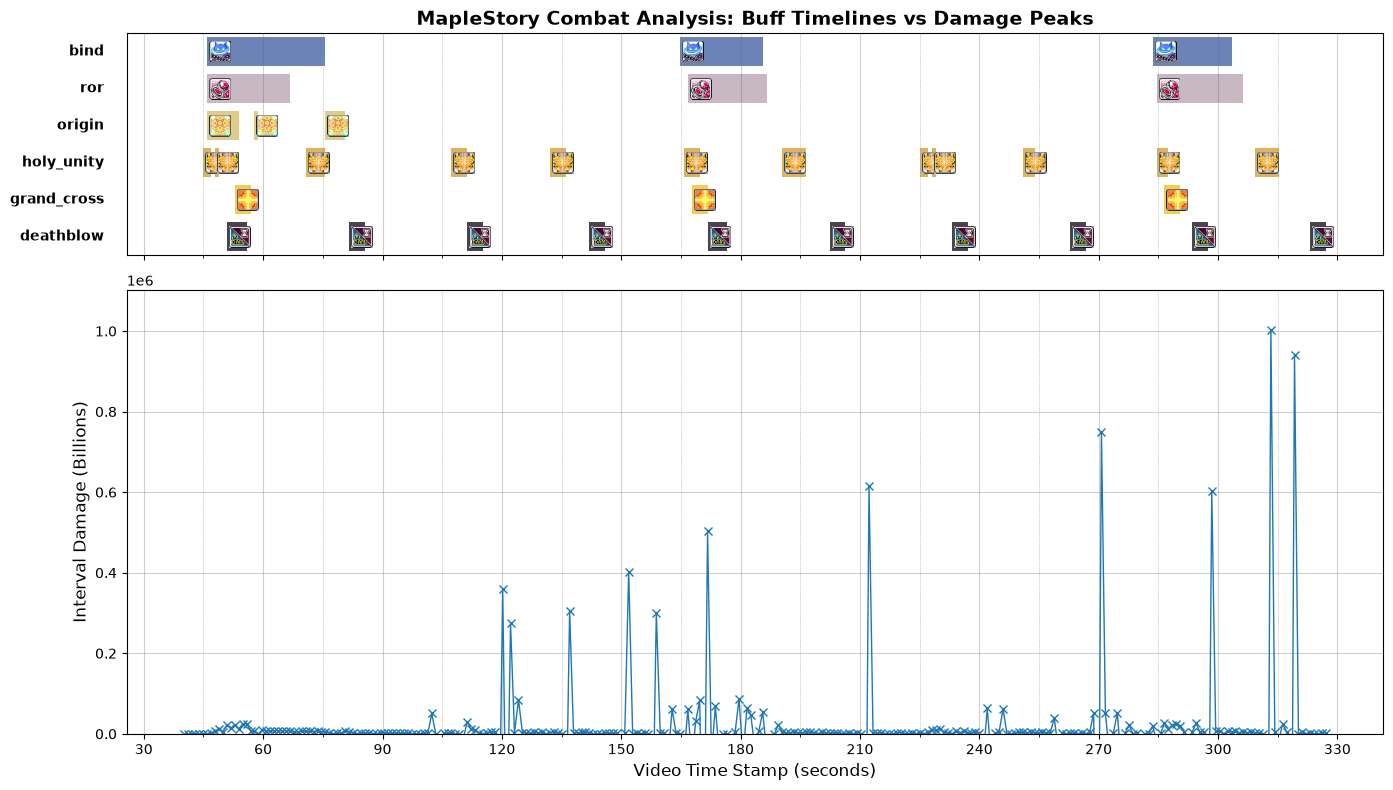

In [9]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd # Kept for 'pd.notna' and general robustness.
from util import get_dominant_colour
import matplotlib.ticker as ticker


# 1. Create a 2-Panel Figure (Top for Buff Timelines, Bottom for Damage)
fig, (ax_buffs, ax_dmg) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                       gridspec_kw={'height_ratios': [1, 2]})

# --- BOTTOM PANEL: DAMAGE GRAPH ---
ax_dmg.plot(df['timestamp'], df['interval_dmg'] / 1e9, color='#1f77b4', marker='x', linewidth=1)
ax_dmg.set_ylabel('Interval Damage (Billions)', fontsize=12)
ax_dmg.set_ylim(bottom=0)
ax_dmg.set_xlabel('Video Time Stamp (seconds)', fontsize=12)
ax_dmg.xaxis.set_major_locator(ticker.MultipleLocator(30))
ax_dmg.xaxis.set_minor_locator(ticker.MultipleLocator(15))
ax_dmg.grid(visible=True, which='major', color='#666666', linestyle='-', linewidth=0.8)
ax_dmg.grid(visible=True, which='minor', color='#999999', linestyle=':', linewidth=0.5)
ax_dmg.grid(True, alpha=0.3)

# --- TOP PANEL: BUFF TRACKS ---
buff_tracks = {
}
y_level = 0
for path in Path(buff_dir).iterdir():
    if not path.is_file():
        continue
    y_level += 1
    skill_name = path.name.replace(".png", "")
    buff_tracks[f"{skill_name}_buff"] = {
        'y_level': y_level,
        'color': get_dominant_colour(path),
        'icon': str(path),
        'label': skill_name,
    }

for path in Path(debuff_dir).iterdir():
    if not path.is_file():
        continue
    y_level += 1
    skill_name = path.name.replace(".png", "")
    buff_tracks[f"{skill_name}_debuff"] = {
        'y_level': y_level,
        'color': get_dominant_colour(path),
        'icon': str(path),
        'label': skill_name,
    }

def add_track_icon(ax, image_path, x_pos, y_pos):
    try:
        img = plt.imread(image_path)
        imagebox = OffsetImage(img, zoom=0.35)
        ab = AnnotationBbox(imagebox, (x_pos, y_pos), frameon=False, xycoords='data', box_alignment=(0, 0.5))
        ax.add_artist(ab)
    except FileNotFoundError:
        ax.text(x_pos, y_pos, "[Icon]", fontsize=8, ha='left', va='center')

for buff_name, config in buff_tracks.items():
    y = config['y_level']
    ax_buffs.text(20, y, config['label'], ha='right', va='center', fontweight='bold', fontsize=10)
    for i in range(len(df)-1):
        if pd.notna(df.loc[i, buff_name]):
            t_start = df.loc[i, 'timestamp']
            t_end = df.loc[i+1, 'timestamp']
            ax_buffs.fill_between([t_start, t_end], y-0.4, y+0.4, color=config['color'], edgecolor='none')
            if i == 0 or pd.isna(df.loc[i-1, buff_name]):
                add_track_icon(ax_buffs, config['icon'], t_start + 0.5, y)

ax_buffs.set_ylim(0.5, len(buff_tracks) + 0.5)
ax_buffs.get_yaxis().set_visible(False)
ax_buffs.grid(True, axis='x', alpha=0.3)
ax_buffs.grid(visible=True, which='major', color='#666666', linestyle='-', linewidth=0.8)
ax_buffs.grid(visible=True, which='minor', color='#999999', linestyle=':', linewidth=0.5)
ax_buffs.set_title('MapleStory Combat Analysis: Buff Timelines vs Damage Peaks', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()